### Import Packages & Load .csv Files

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz, save_npz
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer

CORPUS = pd.read_csv("CORPUS.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|")
VOCAB = pd.read_csv("VOCAB.csv", sep="|")
DTM = load_npz("DTM.npz")
DTM_doc_ids = pd.read_csv("DTM_doc_ids.csv", sep="|") 
DTM_terms = pd.read_csv("DTM_terms.csv", sep="|")

### LDA Topic

In [35]:
# Filter to nouns and verbs only
CORPUS_NV = CORPUS[
    CORPUS["pos"].str.startswith(("NN", "VB"), na=False)
].copy()

# Remove very short tokens
CORPUS_NV = CORPUS_NV[
    CORPUS_NV["term_str"].astype(str).str.len() > 2
]

# Rebuild one document string per doc_id
docs = (
    CORPUS_NV
    .sort_values(["doc_id", "token_id"])
    .groupby("doc_id")["term_str"]
    .apply(lambda x: " ".join(x.astype(str)))
)

# Build count matrix from noun/verb-filtered text
vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.90
)

DTM_NV = vectorizer.fit_transform(docs)
terms_nv = vectorizer.get_feature_names_out()
doc_ids_nv = docs.index.values

# Save DTM_NV
save_npz("DTM_NV.npz", DTM_NV)

In [17]:
# Fit LDA model
n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=0,
    learning_method="batch",
    max_iter=20
)

DOC_TOPIC = lda.fit_transform(DTM_NV)

In [28]:
# Save LDA topic-term matrix
LDA_TOPIC = pd.DataFrame(
    lda.components_,
    columns=terms_nv,
    index=[f"T{i:02d}" for i in range(n_topics)]
)

LDA_TOPIC.to_csv("LDA_TOPIC.csv", sep="|")

LDA_TOPIC.head()

,abandoned,abilities,ability,abnormalities,abortion,above,abscess,absence,absorb,absorbed,...,your,yours,yourself,youth,youtube,zero,zeros,zone,zones,zoom
T00,5.005718,17.300101,56.580322,0.200667,1.830163,2.874587,0.200000,1.872197,0.200985,1.605459,...,0.208576,3.972782,0.206892,12.187250,0.201387,0.209273,1.017231,0.212177,9.188269,9.175619
T01,2.375284,11.098239,38.490687,0.200115,0.200979,0.207308,0.200001,3.595886,0.202253,0.205092,...,1.528445,0.202923,0.201036,0.211713,17.891441,4.390796,5.378343,19.173903,0.201130,0.200001
T02,0.213978,0.200894,12.671703,5.250355,6.544273,4.532920,0.200413,2.468858,0.203383,0.200463,...,3.776530,9.503095,5.188869,0.200433,16.506888,14.969306,0.200048,0.200436,1.188524,0.200265
T03,0.200224,0.200616,21.733929,3.148861,0.224485,0.222906,10.199586,0.677553,10.426605,19.038450,...,1.268720,4.120960,0.203093,0.200187,0.200087,0.204172,0.200003,0.200509,0.200192,0.220888
T04,0.204796,0.200151,8.523360,0.200001,0.200100,8.162280,0.200001,6.385506,15.966775,19.950536,...,0.217729,0.200240,0.200111,0.200417,0.200197,11.226453,0.204375,0.212975,0.221885,0.203227


In [21]:
# Print top 5 words per topic
top_n = 5

for topic_id, topic_weights in enumerate(lda.components_):
    top_indices = topic_weights.argsort()[-top_n:][::-1]
    top_words = terms_nv[top_indices]
    print(f"T{topic_id:02d}: {', '.join(top_words)}")

T00: are, people, was, have, were
T01: are, people, have, money, make
T02: are, have, tax, money, income
T03: are, body, have, credit, help
T04: are, price, water, stock, air


### LDA Theta

In [26]:
LDA_THETA = pd.DataFrame(
    DOC_TOPIC,
    columns=[f"T{i:02d}" for i in range(n_topics)]
)

LDA_THETA["doc_id"] = doc_ids_nv

LDA_THETA.to_csv("LDA_THETA.csv", sep="|", index=False)

LDA_THETA.head()

,T00,T01,T02,T03,T04,doc_id
0,0.016155,0.936930,0.015578,0.015792,0.015544,0
1,0.478853,0.446766,0.004138,0.004173,0.066070,1
2,0.142734,0.856152,0.000367,0.000370,0.000377,2
3,0.002043,0.026310,0.915228,0.054394,0.002025,3
4,0.022635,0.023358,0.526322,0.405283,0.022402,4


### LDA Phi

In [27]:
# Save LDA phi / topic-term matrix
LDA_PHI = pd.DataFrame(
    lda.components_,
    columns=terms_nv,
    index=[f"T{i:02d}" for i in range(n_topics)]
)

# Normalize rows so each topic sums to 1
LDA_PHI = LDA_PHI.div(LDA_PHI.sum(axis=1), axis=0)

LDA_PHI.to_csv("LDA_PHI.csv", sep="|")

LDA_PHI.head()

,abandoned,abilities,ability,abnormalities,abortion,above,abscess,absence,absorb,absorbed,...,your,yours,yourself,youth,youtube,zero,zeros,zone,zones,zoom
T00,0.000056,0.000193,0.000632,0.000002,0.000020,0.000032,0.000002,0.000021,0.000002,0.000018,...,0.000002,0.000044,0.000002,0.000136,0.000002,0.000002,0.000011,0.000002,0.000103,0.000102
T01,0.000034,0.000158,0.000547,0.000003,0.000003,0.000003,0.000003,0.000051,0.000003,0.000003,...,0.000022,0.000003,0.000003,0.000003,0.000254,0.000062,0.000076,0.000273,0.000003,0.000003
T02,0.000004,0.000004,0.000239,0.000099,0.000123,0.000085,0.000004,0.000047,0.000004,0.000004,...,0.000071,0.000179,0.000098,0.000004,0.000311,0.000282,0.000004,0.000004,0.000022,0.000004
T03,0.000004,0.000004,0.000401,0.000058,0.000004,0.000004,0.000188,0.000013,0.000192,0.000351,...,0.000023,0.000076,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004
T04,0.000004,0.000004,0.000152,0.000004,0.000004,0.000145,0.000004,0.000114,0.000284,0.000355,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000200,0.000004,0.000004,0.000004,0.000004


### LDA + PCA Visualization

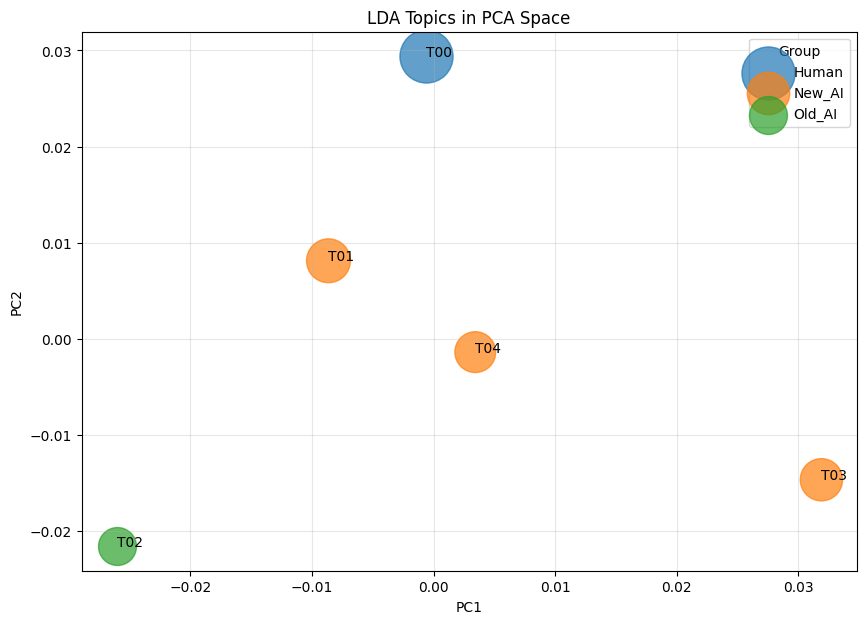

In [33]:
topic_means = LDA_THETA[[f"T{i:02d}" for i in range(n_topics)]].mean()

# Merge theta with metadata
LDA_THETA_META = LDA_THETA.merge(
    LIB[["doc_id", "Group"]],
    on="doc_id",
    how="left"
)

# Assign each doc its dominant topic
LDA_THETA_META["dominant_topic"] = LDA_THETA_META[
    [f"T{i:02d}" for i in range(n_topics)]
].idxmax(axis=1)

# For each topic, get most common Group
topic_group = (
    LDA_THETA_META
    .groupby("dominant_topic")["Group"]
    .agg(lambda x: x.value_counts().index[0])
)

X_topics = LDA_PHI.values  # shape: (topics × terms)

pca = PCA(n_components=2)
topics_2d = pca.fit_transform(X_topics)

PCA_TOPICS = pd.DataFrame(
    topics_2d,
    columns=["PC1", "PC2"],
    index=LDA_PHI.index
)

PCA_TOPICS["mean_weight"] = topic_means.values
PCA_TOPICS["Group"] = topic_group.values

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for group, data in PCA_TOPICS.groupby("Group"):
    plt.scatter(
        data["PC1"],
        data["PC2"],
        s=data["mean_weight"] * 5000,  # scale for visibility
        alpha=0.7,
        label=group
    )

# Label topics
for topic in PCA_TOPICS.index:
    plt.text(
        PCA_TOPICS.loc[topic, "PC1"],
        PCA_TOPICS.loc[topic, "PC2"],
        topic,
        fontsize=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LDA Topics in PCA Space")
plt.legend(title="Group")
plt.grid(True, alpha=0.3)

plt.show()

The PCA projection of LDA topics shows that certain topics (e.g., T03 and T02) are well-separated in PC1, indicating distinct thematic structures, while others like T01 and T04, cluster more closely, suggesting overlapping vocabularies. Topic size reveals that some themes contribute more heavily across the corpus, while color indicates that certain topics are more strongly associated with specific response groups. Overall, the visualization highlights both the diversity and relative importance of learned topics, and a clear visual distiction between Human, Old AI, and New AI responses.